In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

SR_GAUSS_FIELDVARS = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NN_SEEDS           = MODELS['nn']['seeds']
OPTIMIZEDEQS       = MODELS['sr']['optimizedeqs']
ORDER              = ['sr_lo','sr_bl','sr_med','sr_hi']

COLORS = {}
LABELS = {}
for name,cfg in OPTIMIZEDEQS.items():
    COLORS[name] = cfg['color']
    LABELS[name] = cfg['description']

NBINS   = 20
MINSAMP = 30

In [4]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields*weights[None,:,:]*dsig[None,None,:]
    if mask is not None:
        w = w*mask[:,None,:]
    return w.sum(axis=2)

def to_phys(srout):
    return np.expm1(tpstd*np.maximum(0.0,np.asarray(srout,dtype=float)))

SRFUNCTIONS = {
    'cube':lambda x:x**3,
    'square':lambda x:x**2,
    'neg':lambda x:-x,
    'sqrt':np.sqrt,
    'exp':np.exp,
    'log':np.log,
    'abs':np.abs,
    'max':np.maximum,
    'min':np.minimum}

def eval_form(form,variables,constants):
    ns = dict(SRFUNCTIONS)
    ns.update(variables)
    ns.update(constants)
    return np.asarray(eval(form,{'__builtins__':{}},ns),dtype=float)

def used_predictors(form,candidates):
    names = {n.id for n in ast.walk(ast.parse(form,mode='eval')) if isinstance(n,ast.Name)}
    return [c for c in candidates if c in names]

def bin1d(x,z,nbins=NBINS,minsamp=MINSAMP,plo=1,phi=99):
    '''Binned mean of z vs x using evenly-spaced value bins (not quantile bins).'''
    finite = np.isfinite(x)&np.isfinite(z)
    x,z    = x[finite],z[finite]
    lo,hi  = np.percentile(x,[plo,phi])
    edges  = np.linspace(lo,hi,nbins+1)
    xi     = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    means  = np.full(nbins,np.nan)
    for i in range(nbins):
        sel = xi==i
        if sel.sum()>=minsamp:
            means[i] = z[sel].mean()
    return 0.5*(edges[:-1]+edges[1:]),means

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])
zmin   = (0.0-tpmean)/tpstd

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = ds.sizes['time'],ds.sizes['lat'],ds.sizes['lon']
    nsig            = ds.sizes.get('sig',1)
    dsig            = ds['dsig'].values
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in SR_GAUSS_FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)
    def getflat(da):
        if 'time' in da.dims:
            return da.transpose('time','lat','lon').values.ravel()
        return np.tile(da.values,(ntime,1,1)).ravel()
    blnorm  = getflat(ds['bl'])
    lfnorm  = getflat(ds['lf'])
    shfnorm = getflat(ds['shf'])

kwlist = []
for seed in NN_SEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)

ki = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0) if kwlist else fieldstack.mean(axis=2)
rhk,thetaek,thetaestark = ki[:,0],ki[:,1],ki[:,2]

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time','lat','lon').values.ravel()

with open(os.path.join(MODELSDIR,'sr','optimized_equations.pkl'),'rb') as f:
    SR_REGISTRY = pickle.load(f)

In [6]:
VARS = {'bl':blnorm,'rh':rhk,'thetae':thetaek,'thetaestar':thetaestark,'lf':lfnorm,'shf':shfnorm}

MODELPRED = {}
MODELPREDICTORS = {}
for name,cfg in OPTIMIZEDEQS.items():
    entry          = SR_REGISTRY.get(name,{})
    form           = entry.get('form',cfg['form'])
    constants      = entry.get('constants',cfg['init'])
    predictornames = used_predictors(form,VARS.keys())
    variables      = {p:VARS[p] for p in predictornames}
    formvals       = eval_form(form,variables,constants)
    MODELPRED[name]       = to_phys(formvals)
    MODELPREDICTORS[name] = predictornames

In [12]:
PHYSUNITS  = {'bl':'m/s$^2$','rh':'%','thetae':'K','thetaestar':'K','lf':'0-1','shf':'W/m$^2$'}
PHYSLABELS = {'bl':'BL','rh':'RH','thetae':r'$\theta_e$','thetaestar':r'$\theta_e^*$','lf':'LF','shf':'SHF'}

PREDICTORS = []
for p in ['bl','rh','thetae','thetaestar','lf','shf']:
    models = [name for name in OPTIMIZEDEQS if p in MODELPREDICTORS[name]]
    if models:
        PREDICTORS.append((p,models))

valid = np.isfinite(obsflat)
for arr in VARS.values():
    valid &= np.isfinite(arr)
for arr in MODELPRED.values():
    valid &= np.isfinite(arr)

print(f'Valid samples: {valid.sum():,}')
print(PREDICTORS)

Valid samples: 1,437,408
[('bl', ['sr_bl']), ('rh', ['sr_lo', 'sr_med', 'sr_hi']), ('thetae', ['sr_med', 'sr_hi']), ('thetaestar', ['sr_med', 'sr_hi']), ('lf', ['sr_hi']), ('shf', ['sr_hi'])]


In [15]:
def plot_dependence(savepath):
    fig,axs = pplt.subplots(nrows=2,ncols=3,figwidth=6.5,sharex=False,sharey=True)
    for ax,(p,models) in zip(axs,PREDICTORS):
        x = VARS[p][valid]*STATS[f'{p}_std']+STATS[f'{p}_mean']
        xc,obsbin = bin1d(x,obsflat[valid])
        ax.plot(xc,obsbin,color='k',linewidth=2,label='Observed',zorder=5)
        for name in ORDER:
            if name not in models:
                continue
            _,predbin = bin1d(x,MODELPRED[name][valid])
            ax.plot(xc,predbin,color=COLORS[name],linewidth=1.5,label=LABELS[name])
        ax.format(grid=False,xlabel=f'{PHYSLABELS[p]} ({PHYSUNITS[p]})')
    axs[:,0].format(ylabel='Precipitation (mm)',ylim=(0,5))
    handles = [Line2D([],[],color='k',linewidth=2,label='Observed')]
    handles += [Line2D([],[],color=COLORS[name],linewidth=1.5,label=LABELS[name]) for name in ORDER]
    fig.legend(handles,loc='r',ncols=1)
    # fig.format(abc=True,abcloc='ul')
    pplt.show()
    fig.save(savepath)
    return fig

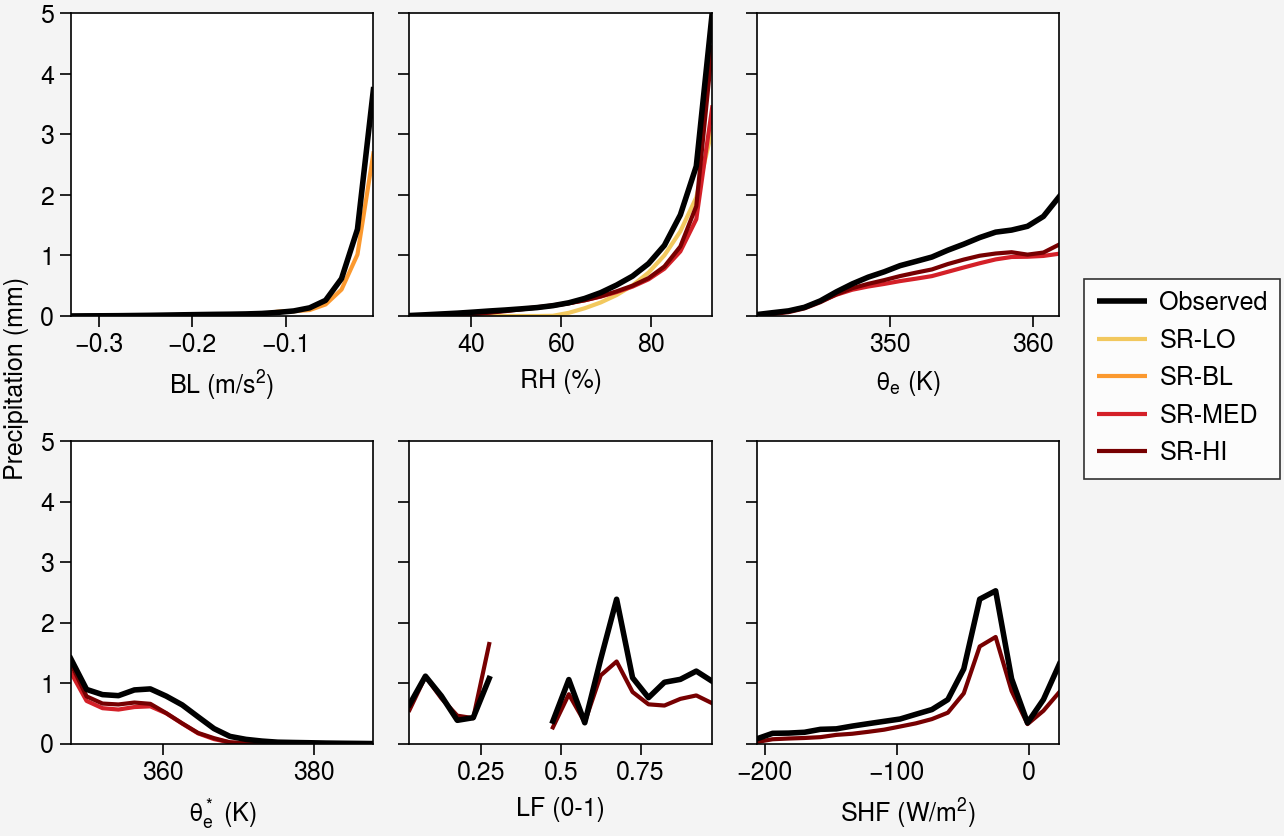

In [ ]:
fig = plot_dependence(savepath='../figs/dependence_denormalized.jpg')